In [1]:
import warnings
warnings.filterwarnings('ignore')
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

%matplotlib inline

In [2]:
df = pd.read_csv('diabetes.csv')

In [3]:
df.shape

(768, 9)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [5]:
df.describe()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


In [6]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

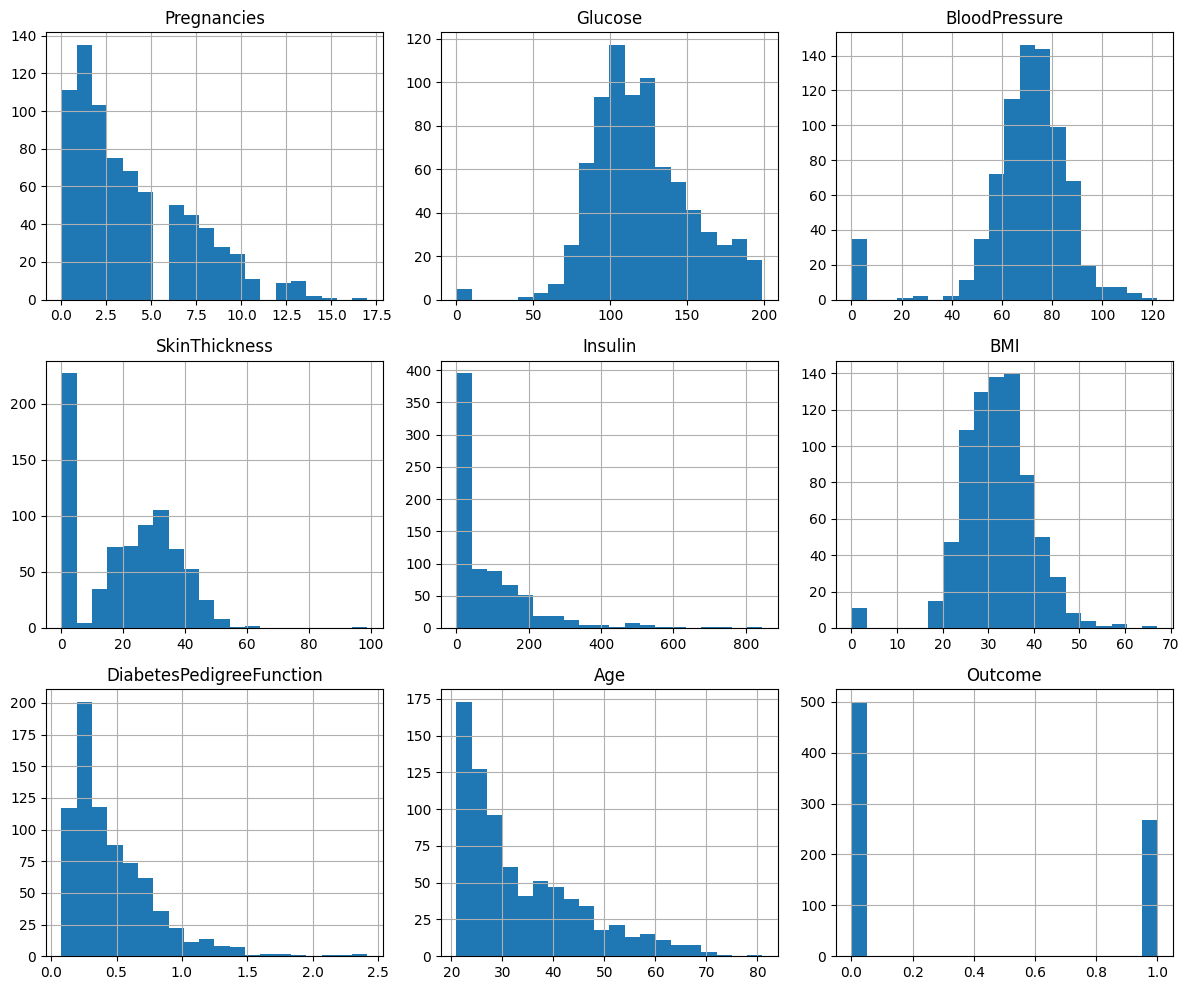

In [7]:
df.hist(figsize=(12, 10), bins=20)
plt.tight_layout()
plt.show()

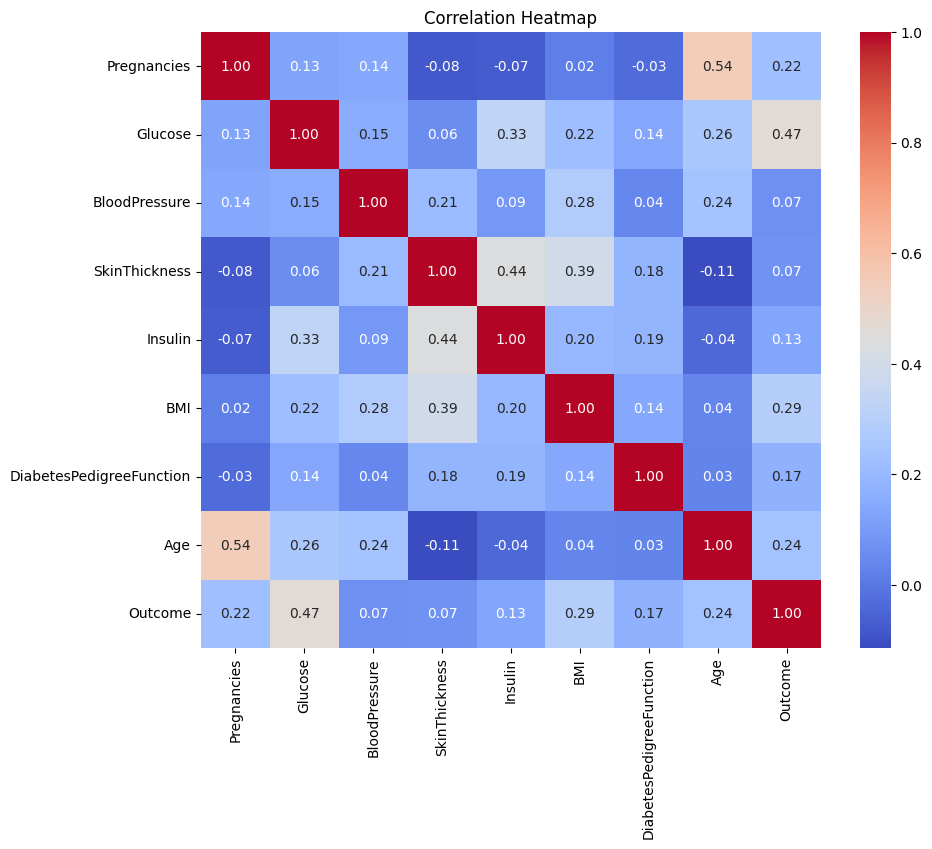

In [8]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

In [9]:
x = df.drop(columns='Outcome')
y = df['Outcome']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

In [10]:
sc = StandardScaler()
x_train_scaled = sc.fit_transform(x_train)
x_test_scaled = sc.transform(x_test)

In [11]:
xgb = XGBClassifier(random_state=42)
xgb.fit(x_train_scaled, y_train)

,"base_score base_score: typing.Union[float, typing.List[float], NoneType]The initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.Optional[typing.List[xgboost.callback.TrainingCallback]]List of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API <callback_api>`... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: typing.Optional[float]Subsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: typing.Optional[float]Subsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: typing.Optional[float]Subsample ratio of columns when constructing each tree.,None
,"device device: typing.Optional[str].. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: typing.Optional[int].. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: typing.Union[str, typing.List[typing.Union[str, typing.Callable]], typing.Callable, NoneType].. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_method=""hist"", eval_metric=mean_absolute_error, ) reg.fit(X, y, eval_set=[(X, y)])",None
,feature_types feature_types: typing.Optional[typing.Sequence[str]].. versionadded:: 1.7.0Used for specifying feature types without constructing a dataframe. Seethe :py:class:`DMatrix` for details.,None


In [12]:
y_pred_xgb = xgb.predict(x_test_scaled)
y_prob_xgb = xgb.predict_proba(x_test_scaled)[:, 1]
acc_xgb = accuracy_score(y_test, y_pred_xgb)
prec_xgb = precision_score(y_test, y_pred_xgb)
rec_xgb = recall_score(y_test, y_pred_xgb)
f1_xgb = f1_score(y_test, y_pred_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)

print(f"XGBoost Accuracy: {acc_xgb:.4f}")
print(f"XGBoost Precision: {prec_xgb:.4f}")
print(f"XGBoost Recall: {rec_xgb:.4f}")
print(f"XGBoost F1-Score: {f1_xgb:.4f}")
print(f"XGBoost ROC-AUC: {auc_xgb:.4f}")

XGBoost Accuracy: 0.7208
XGBoost Precision: 0.5909
XGBoost Recall: 0.7091
XGBoost F1-Score: 0.6446
XGBoost ROC-AUC: 0.7761


In [13]:
lgb = LGBMClassifier(random_state=42, verbose=-1)
lgb.fit(x_train_scaled, y_train)

,random_state,42
,verbose,-1
,boosting_type,'gbdt'
,num_leaves,31
,max_depth,-1
,learning_rate,0.1
,n_estimators,100
,subsample_for_bin,200000
,objective,None
,class_weight,None
,min_split_gain,0.0


In [14]:
y_pred_lgb = lgb.predict(x_test_scaled)
y_prob_lgb = lgb.predict_proba(x_test_scaled)[:, 1]
acc_lgb = accuracy_score(y_test, y_pred_lgb)
prec_lgb = precision_score(y_test, y_pred_lgb)
rec_lgb = recall_score(y_test, y_pred_lgb)
f1_lgb = f1_score(y_test, y_pred_lgb)
auc_lgb = roc_auc_score(y_test, y_prob_lgb)

print(f"LightGBM Accuracy: {acc_lgb:.4f}")
print(f"LightGBM Precision: {prec_lgb:.4f}")
print(f"LightGBM Recall: {rec_lgb:.4f}")
print(f"LightGBM F1-Score: {f1_lgb:.4f}")
print(f"LightGBM ROC-AUC: {auc_lgb:.4f}")

LightGBM Accuracy: 0.7078
LightGBM Precision: 0.5781
LightGBM Recall: 0.6727
LightGBM F1-Score: 0.6218
LightGBM ROC-AUC: 0.7624


In [15]:
param_grid = {'max_depth': [3, 5], 'learning_rate': [0.01, 0.1], 'n_estimators': [50, 100]}
grid_xgb = GridSearchCV(XGBClassifier(random_state=42), param_grid, cv=3, refit=True)
grid_xgb.fit(x_train_scaled, y_train)
print("Best XGBoost parameters:", grid_xgb.best_params_)

Best XGBoost parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}


In [16]:
grid_lgb = GridSearchCV(LGBMClassifier(random_state=42, verbose=-1), param_grid, cv=3, refit=True)
grid_lgb.fit(x_train_scaled, y_train)
print("Best LightGBM parameters:", grid_lgb.best_params_)

Best LightGBM parameters: {'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}


In [17]:
y_pred_xgb_t = grid_xgb.predict(x_test_scaled)
y_prob_xgb_t = grid_xgb.predict_proba(x_test_scaled)[:, 1]
acc_xgb_t = accuracy_score(y_test, y_pred_xgb_t)
prec_xgb_t = precision_score(y_test, y_pred_xgb_t)
rec_xgb_t = recall_score(y_test, y_pred_xgb_t)
f1_xgb_t = f1_score(y_test, y_pred_xgb_t)
auc_xgb_t = roc_auc_score(y_test, y_prob_xgb_t)

y_pred_lgb_t = grid_lgb.predict(x_test_scaled)
y_prob_lgb_t = grid_lgb.predict_proba(x_test_scaled)[:, 1]
acc_lgb_t = accuracy_score(y_test, y_pred_lgb_t)
prec_lgb_t = precision_score(y_test, y_pred_lgb_t)
rec_lgb_t = recall_score(y_test, y_pred_lgb_t)
f1_lgb_t = f1_score(y_test, y_pred_lgb_t)
auc_lgb_t = roc_auc_score(y_test, y_prob_lgb_t)

comp_df = pd.DataFrame({
    'Model': ['XGBoost Base', 'LightGBM Base', 'XGBoost Tuned', 'LightGBM Tuned'],
    'Accuracy': [acc_xgb, acc_lgb, acc_xgb_t, acc_lgb_t],
    'Precision': [prec_xgb, prec_lgb, prec_xgb_t, prec_lgb_t],
    'Recall': [rec_xgb, rec_lgb, rec_xgb_t, rec_lgb_t],
    'F1-Score': [f1_xgb, f1_lgb, f1_xgb_t, f1_lgb_t],
    'ROC-AUC': [auc_xgb, auc_lgb, auc_xgb_t, auc_lgb_t]
})
print(comp_df)

            Model  Accuracy  Precision    Recall  F1-Score   ROC-AUC
0    XGBoost Base  0.720779   0.590909  0.709091  0.644628  0.776125
1   LightGBM Base  0.707792   0.578125  0.672727  0.621849  0.762351
2   XGBoost Tuned  0.753247   0.654545  0.654545  0.654545  0.816896
3  LightGBM Tuned  0.740260   0.631579  0.654545  0.642857  0.811754
